### Monthly & Seasonal Analysis

In [3]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Paths and constants
DATA_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/model_outputs"
OUTPUT_DIR = "/home/rosquete/Documents/FRESH-CARE/data/fusion_evaluation/classic_evaluation/results"

# Colors
MODEL_COLORS = {
    'ADT-0.25': 'red',
    'ADT-SSS': 'magenta',
    'ADT-SST': 'blue',
    'OSCAR-geos': 'green'
}

In [5]:
# Loading data
os.chdir(DATA_DIR)
files = {
    'ADT-0.25': 'ADT-0.25_interpolated.parquet',
    'ADT-SSS': 'ADT-SSS_interpolated.parquet',
    'ADT-SST': 'ADT-SST_interpolated.parquet',
    'OSCAR-geos': 'OSCAR-geos_interpolated.parquet'
}

all_data = []

for name, path in files.items():
    df = pd.read_parquet(path)

    # Rename dataset columns for consistency
    df = df.rename(columns={
        'vn': 'v_obs',
        've': 'u_obs'
    })

    # Model name
    df['model_name'] = name

    # Adding scalar speed columns
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)

    # Bias columns
    df['err_u'] = df['u_model'] - df['u_obs']
    df['err_v'] = df['v_model'] - df['v_obs']
    df['err_speed'] = df['speed_model'] - df['speed_obs']

    # Temporal columns
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['year'] = df['time'].dt.year

    # Seasons
    df['season'] = df['month'].map({
        12:'Winter', 1:'Winter', 2:'Winter',
        3:'Spring', 4:'Spring', 5:'Spring',
        6:'Summer', 7:'Summer', 8:'Summer',
        9:'Autumn', 10:'Autumn', 11:'Autumn'
    })
    
    all_data.append(df)


# Combine all dataframes into one master dataframe
master_df = pd.concat(all_data, ignore_index=True)

# Better memory usage
master_df['model_name'] = master_df['model_name'].astype('category')
master_df['id_sector'] = master_df['id_sector'].astype('category')
master_df['season'] = master_df['season'].astype('category')

In [7]:
# Metrics Calculation
def get_metrics(x):
    """Calculate RMSE, Bias, and Correlation for Speed, U, and V."""
    stats = {}
    
    # Define the pairs to evaluate
    pairs = {
        'Speed': ('speed_model', 'speed_obs', 'err_speed'),
        'U': ('u_model', 'u_obs', 'err_u'),
        'V': ('v_model', 'v_obs', 'err_v')
    }
    
    for label, (mod, obs, err) in pairs.items():
        stats[f'RMSE_{label}'] = np.sqrt(np.mean(x[err]**2))
        stats[f'Bias_{label}'] = np.mean(x[err])
        stats[f'Corr_{label}'] = x[obs].corr(x[mod])
        stats[f'STD_{label}'] = np.std(x[err])
        
    return pd.Series(stats)


In [12]:
# Monthly metrics

# Run the grouping
monthly_stats = (
    master_df.groupby(['model_name', 'month'], observed=True)
    .apply(get_metrics, include_groups=False)
    .reset_index()
)

def plot_monthly_metric(df, metric_name, ylabel):
    """Function to plot monthly metrics."""
    plt.figure(figsize=(8, 4))
    
    for model in df['model_name'].unique():
        subset = df[df['model_name'] == model].sort_values('month')
        plt.plot(subset['month'], subset[metric_name], 
                 marker='o', label=model, color=MODEL_COLORS[model])

    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']) 
    plt.xlabel('Month') 
    plt.ylabel(ylabel) 
    plt.grid(True, alpha=0.3) 
    plt.legend(loc='best')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{metric_name}_monthly.png'), dpi=300, bbox_inches='tight')
    plt.show()

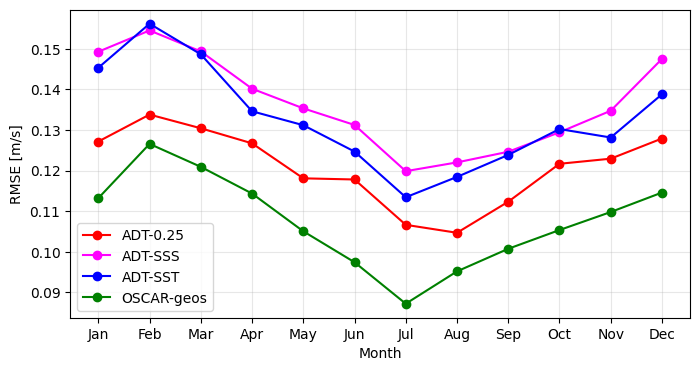

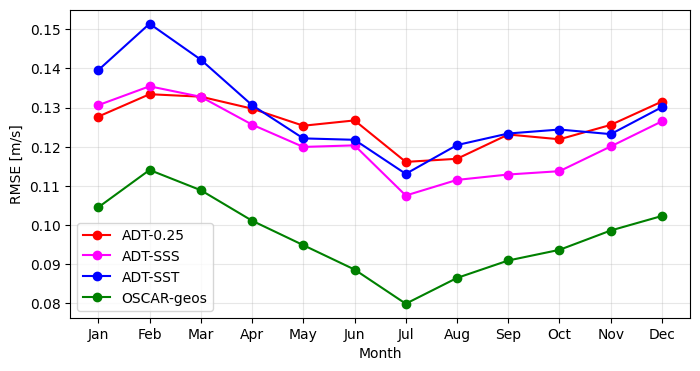

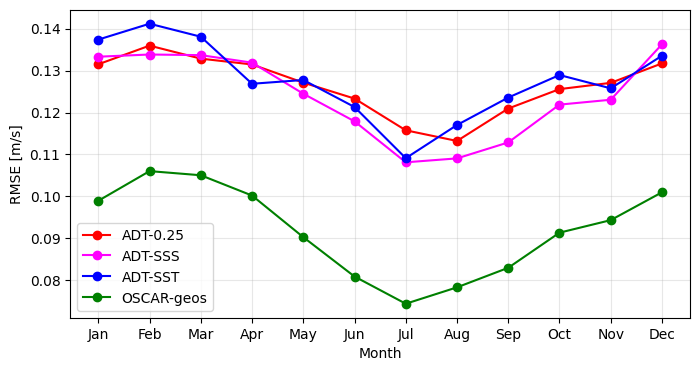

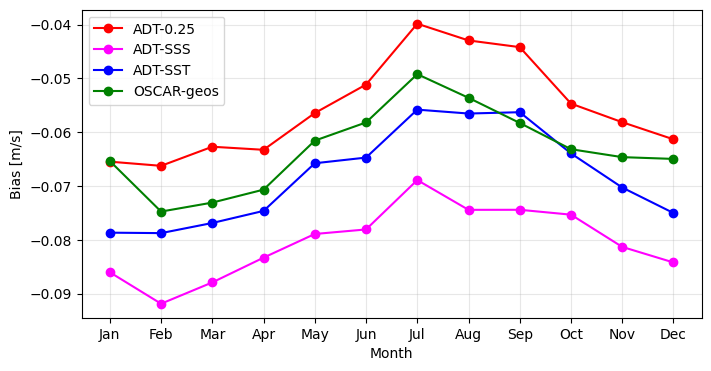

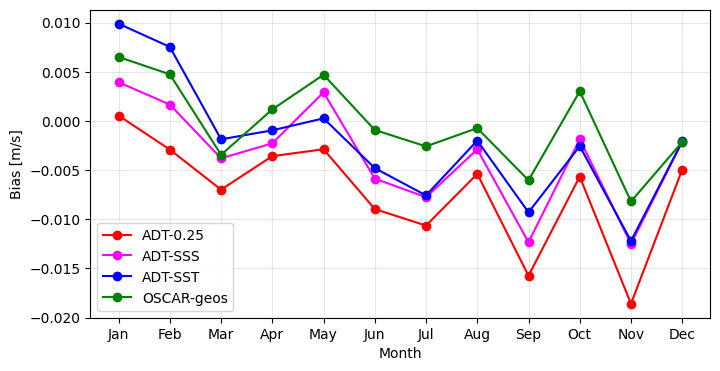

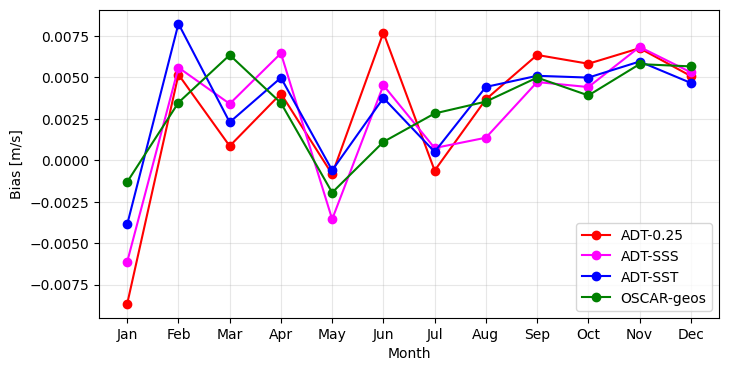

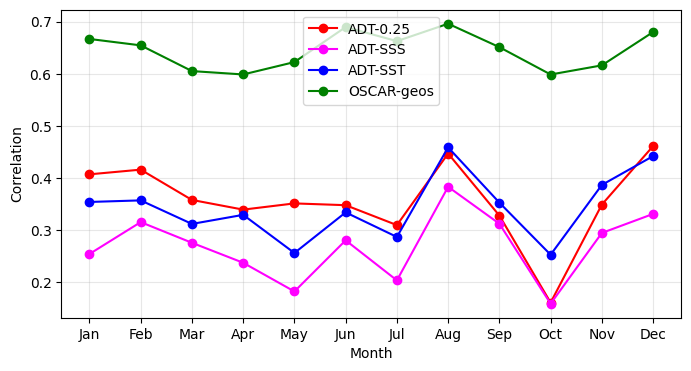

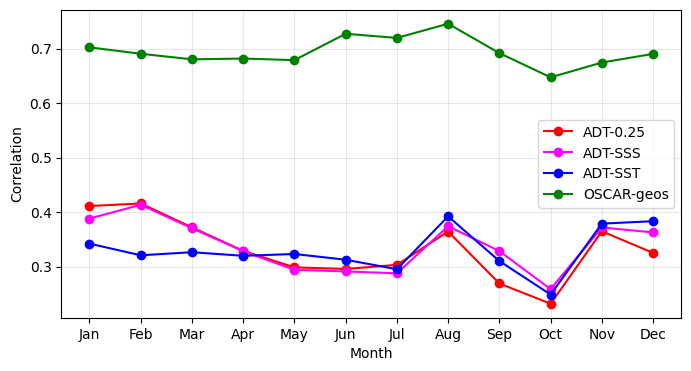

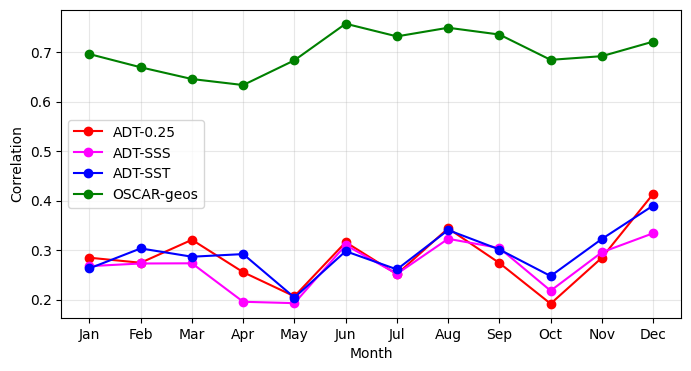

In [13]:
# Monthly RMSE Plots
plot_monthly_metric(monthly_stats, 'RMSE_Speed', 'RMSE [m/s]')
plot_monthly_metric(monthly_stats, 'RMSE_U', 'RMSE [m/s]')
plot_monthly_metric(monthly_stats, 'RMSE_V', 'RMSE [m/s]')

# Monthly Bias Plots
plot_monthly_metric(monthly_stats, 'Bias_Speed', 'Bias [m/s]')
plot_monthly_metric(monthly_stats, 'Bias_U', 'Bias [m/s]')
plot_monthly_metric(monthly_stats, 'Bias_V', 'Bias [m/s]')

# Monthly Correlation Plots
plot_monthly_metric(monthly_stats, 'Corr_Speed', 'Correlation')
plot_monthly_metric(monthly_stats, 'Corr_U', 'Correlation')
plot_monthly_metric(monthly_stats, 'Corr_V', 'Correlation')

In [16]:
# Seasonal Analysis
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn'] 

seasonal_stats = (
    master_df.groupby(['model_name', 'season'], observed=True)
    .apply(get_metrics, include_groups=False)
    .reset_index()
)


def plot_seasonal_metric(df, metric_name, ylabel, title_name=None):
    """
    Plots grouped bar charts for seasonal metrics for Speed, U, and
    V components.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Define x positions and width
    models = df['model_name'].unique()
    x = np.arange(len(SEASON_ORDER)) 
    width = 0.15  
    
    # Plot bars for each model side-by-side 
    for i, model in enumerate(models):
        subset = df[df['model_name'] == model].sort_values('season')
        # Offset each model's bar by the width 
        ax.bar(x + (i * width), subset[metric_name], width, 
               label=model, color=MODEL_COLORS[model], alpha=0.8)

    # Formatting
    ax.set_xticks(x + width * (len(models) - 1) / 2) 
    ax.set_xticklabels(SEASON_ORDER)
    ax.set_xlabel('Season')
    ax.set_ylabel(ylabel)
    
    if title_name:
        ax.set_title(title_name)
    
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    ax.grid(True, alpha=0.3, axis='y') 
    ax.legend(frameon=True, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(models))
    
    # Save and show 
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'seasonal_{metric_name.lower()}.png'), dpi=300, bbox_inches='tight')
    plt.show()


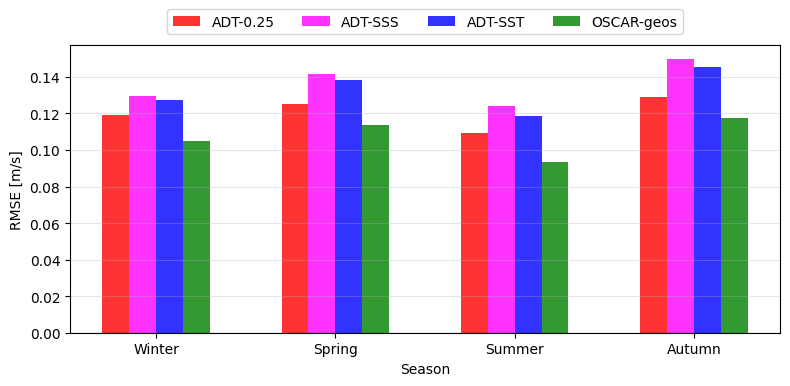

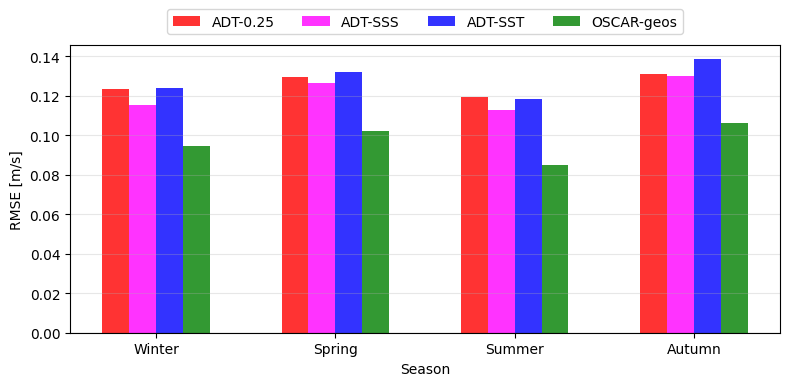

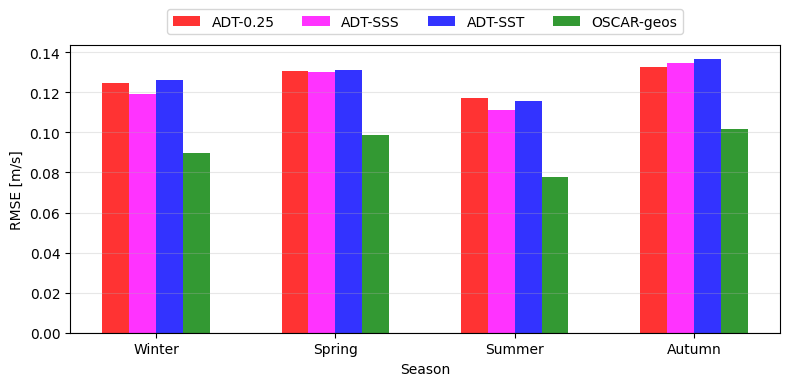

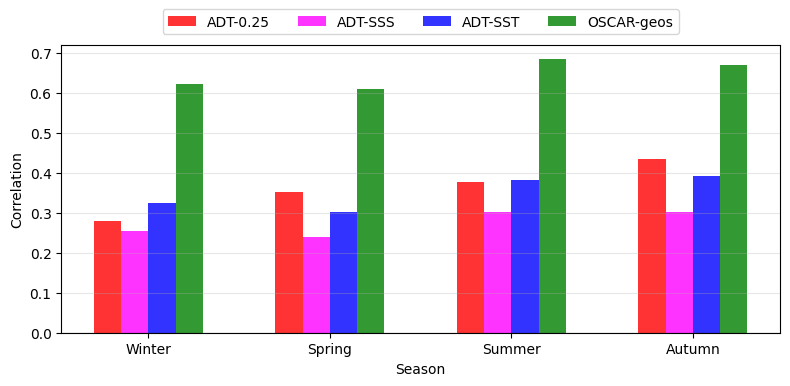

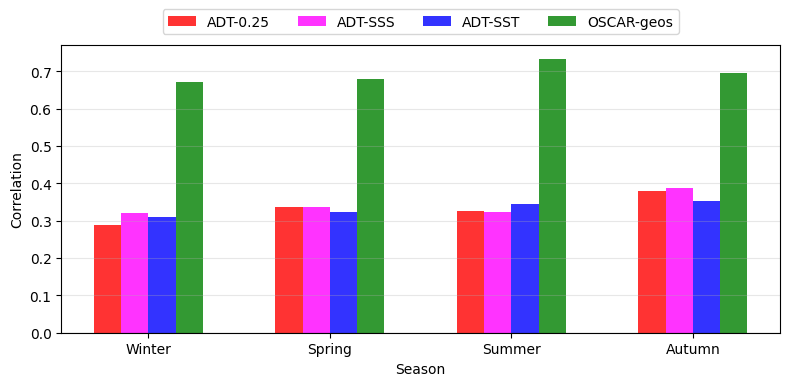

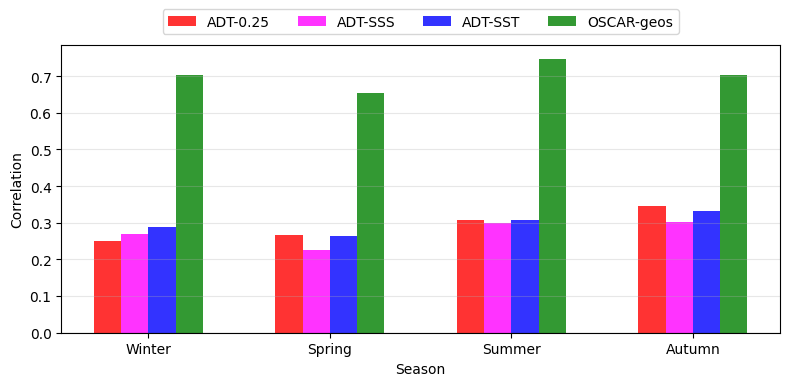

In [17]:
# Seasonal RMSE Plots
plot_seasonal_metric(seasonal_stats, 'RMSE_Speed', 'RMSE [m/s]')
plot_seasonal_metric(seasonal_stats, 'RMSE_U', 'RMSE [m/s]')
plot_seasonal_metric(seasonal_stats, 'RMSE_V', 'RMSE [m/s]')

# # Seasonal Bias Plots
# plot_seasonal_metric(seasonal_stats, 'Bias_Speed', 'Bias [m/s]')
# plot_seasonal_metric(seasonal_stats, 'Bias_U', 'Bias [m/s]')
# plot_seasonal_metric(seasonal_stats, 'Bias_V', 'Bias [m/s]')

# Seasonal Correlation Plots
plot_seasonal_metric(seasonal_stats, 'Corr_Speed', 'Correlation')
plot_seasonal_metric(seasonal_stats, 'Corr_U', 'Correlation')
plot_seasonal_metric(seasonal_stats, 'Corr_V', 'Correlation')